# Anomaly Analysis & Sensor Clustering
**Thesis:** Structured Subsystem-Aware Feature Representations for Predictive Maintenance in Metro Systems  
**Author:** Emirhan Kurtulus

**Goal:** Identify which of the 101 sensors show precursor signals before failures, and cluster sensors by their anomaly behavior to validate subsystem-aware feature grouping.

**Inputs:** Raw train/test parquet data, failure events  
**Outputs:** Sensor ranking by precursor strength, data-driven sensor clusters

## 0. Imports & Setup

In [ ]:
import sys, os, gc
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
from src.config import (
    TRAIN_GLOB_PORTABLE as TRAIN_PATH,
    TEST_GLOB_PORTABLE as TEST_PATH,
    SUBSYSTEMS, ALL_SENSOR_COLS
)

plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['font.size'] = 11

# Reverse lookup: column -> subsystem
_col_to_subsystem = {col: ss for ss, cols in SUBSYSTEMS.items() for col in cols}
def get_subsystem(col):
    return _col_to_subsystem.get(col, 'Context')

META_COLS = ['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE',
             'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE',
             'year', 'month', 'day']

print('Setup done.')

## 1. Load Data & Extract Failure Events

We only load the **train set** for this analysis — failure events from train are used to discover precursor patterns.  
Test set is held out for final model evaluation.

In [ ]:
def load_split(path_pattern, label):
    files = sorted(glob.glob(path_pattern, recursive=True))
    print(f'[{label}] Loading {len(files)} files...')
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
    df.sort_values('TIMESTAMP', inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'[{label}] {len(df):,} rows | {df["TIMESTAMP"].min().date()} -> {df["TIMESTAMP"].max().date()}')
    return df

train = load_split(TRAIN_PATH, 'TRAIN')
gc.collect()

# Sensor columns (exclude meta/label columns)
sensor_cols = [c for c in train.columns if c not in META_COLS]
print(f'\nSensor columns: {len(sensor_cols)}')

In [ ]:
def get_failure_events(df):
    """Extract failure events as continuous True blocks in TRAIN_IS_IN_FAILURE."""
    tmp = df[['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE']].copy()
    tmp['_grp'] = (tmp['TRAIN_IS_IN_FAILURE'] != tmp['TRAIN_IS_IN_FAILURE'].shift()).cumsum()
    events = (
        tmp[tmp['TRAIN_IS_IN_FAILURE']]
        .groupby('_grp')
        .agg(
            start=('TIMESTAMP', 'min'),
            end=('TIMESTAMP', 'max'),
            failure_type=('TRAIN_FAILURE_TYPE', 'first'),
            n_rows=('TIMESTAMP', 'count')
        )
        .reset_index(drop=True)
    )
    events.index = events.index + 1
    events.index.name = 'event'
    events['duration_h'] = (events['end'] - events['start']).dt.total_seconds() / 3600
    return events

train_events = get_failure_events(train)

print(f'Train failure events: {len(train_events)}')
print(train_events[['start', 'end', 'duration_h', 'failure_type']].to_string())
print()

# Summary by type
from collections import Counter
type_counts = Counter(train_events['failure_type'])
for t, n in type_counts.items():
    print(f'  {t}: {n}')

## 2. Precursor Variance for All Sensors

For each of the 10 train failure events and each of the 101 sensors, we compute:

1. **Normal variance** — rolling variance in the first 4 hours of the 24h lookback window (baseline behavior)
2. **Peak variance** — maximum rolling variance in the pre-onset window (potential precursor spike)
3. **Variance ratio** — `peak_var / normal_var` — how many times stronger the spike is vs. baseline

A high variance ratio (e.g. > 5) means the sensor showed abnormal fluctuation before the failure.

The rolling window size is 410s (decorrelation time from Steiner RAMS 2026).

In [ ]:
TAU_CORR_S  = 410    # rolling variance window (Steiner RAMS 2026)
LOOKBACK_H  = 24     # hours before failure onset
NORMAL_H    = 4      # first N hours of lookback used as "normal" baseline

ts = train['TIMESTAMP']
results = []

for idx, event in train_events.iterrows():
    t_onset    = event['start']
    win_start  = t_onset - pd.Timedelta(hours=LOOKBACK_H)
    normal_end = win_start + pd.Timedelta(hours=NORMAL_H)

    # Efficient index lookup
    i0 = ts.searchsorted(win_start)
    i1 = ts.searchsorted(t_onset, side='right')

    if i1 - i0 < TAU_CORR_S:
        print(f'Event {idx}: not enough data in window, skipping')
        continue

    # Index boundary for normal period
    i_normal_end = ts.searchsorted(normal_end, side='right')

    print(f'Event {idx} ({event["failure_type"][:15]:15s}) | '
          f'window rows: {i1-i0:,} | normal rows: {i_normal_end-i0:,}')

    # Process each sensor one at a time (memory-efficient)
    for sensor in sensor_cols:
        col_data = train[sensor].iloc[i0:i1].values

        # Rolling variance
        s = pd.Series(col_data)
        rv = s.rolling(TAU_CORR_S, min_periods=60).var().values

        # Normal variance = median of rolling var in first NORMAL_H hours
        normal_rv = rv[:i_normal_end - i0]
        normal_var = float(np.nanmedian(normal_rv)) if len(normal_rv) > 0 else np.nan

        # Peak variance = max rolling var in full pre-onset window
        peak_var = float(np.nanmax(rv)) if len(rv) > 0 else np.nan

        # Lead time = how many hours before onset the peak occurs
        peak_idx = np.nanargmax(rv) if len(rv) > 0 else 0
        lead_s = (i1 - i0) - peak_idx  # samples from peak to onset
        lead_h = lead_s / 3600

        # Variance ratio
        if normal_var and normal_var > 1e-12:
            var_ratio = peak_var / normal_var
        else:
            var_ratio = np.nan

        results.append({
            'event': idx,
            'failure_type': event['failure_type'],
            'sensor': sensor,
            'subsystem': get_subsystem(sensor),
            'normal_var': normal_var,
            'peak_var': peak_var,
            'var_ratio': var_ratio,
            'lead_h': round(lead_h, 2),
        })

precursor_df = pd.DataFrame(results)
print(f'\nDone: {len(precursor_df):,} rows ({len(sensor_cols)} sensors x {len(train_events)} events)')
gc.collect()

In [ ]:
# Build the variance ratio matrix: sensors (rows) x events (columns)
var_ratio_matrix = precursor_df.pivot(index='sensor', columns='event', values='var_ratio')

# Add subsystem label for each sensor
var_ratio_matrix['subsystem'] = var_ratio_matrix.index.map(get_subsystem)

# Sort by subsystem then sensor name for readability
var_ratio_matrix = var_ratio_matrix.sort_values(['subsystem', var_ratio_matrix.index.name])

print(f'Variance ratio matrix: {var_ratio_matrix.shape[0]} sensors x {len(train_events)} events')
print(f'NaN entries (sensor was constant / zero variance in normal period): '
      f'{var_ratio_matrix.drop(columns="subsystem").isna().sum().sum()}')
print()

# Show a preview: top 10 sensors by median variance ratio
event_cols = [c for c in var_ratio_matrix.columns if c != 'subsystem']
var_ratio_matrix['median_ratio'] = var_ratio_matrix[event_cols].median(axis=1)
top10 = var_ratio_matrix.nlargest(10, 'median_ratio')
print('Top 10 sensors by median variance ratio across events:')
print(top10[event_cols + ['subsystem', 'median_ratio']].round(1).to_string())

## 3. Rank Sensors by Precursor Strength

For each sensor we compute three metrics across the 10 train events:
- **Detection rate** — fraction of events where `var_ratio > 5` (i.e., the sensor detected a precursor)
- **Median variance ratio** — overall signal strength
- **Median lead time** — how early (in hours) the peak variance occurs before failure onset

Sensors with high detection rate AND high variance ratio are reliable precursors.  
Sensors with low scores across all events can be dropped from the feature set.

In [ ]:
DETECTION_THRESHOLD = 5  # var_ratio above this = "detected"

# Compute per-sensor summary stats
sensor_ranking = (
    precursor_df.groupby(['sensor', 'subsystem'])
    .agg(
        n_events=('var_ratio', 'count'),
        n_detected=('var_ratio', lambda x: (x > DETECTION_THRESHOLD).sum()),
        median_ratio=('var_ratio', 'median'),
        max_ratio=('var_ratio', 'max'),
        median_lead_h=('lead_h', 'median'),
    )
    .reset_index()
)
sensor_ranking['detection_rate'] = (sensor_ranking['n_detected'] / sensor_ranking['n_events']).round(2)

# Sort by detection rate first, then median ratio
sensor_ranking = sensor_ranking.sort_values(
    ['detection_rate', 'median_ratio'], ascending=[False, False]
).reset_index(drop=True)

print(f'Total sensors ranked: {len(sensor_ranking)}')
print(f'Sensors with detection rate >= 0.5: {(sensor_ranking["detection_rate"] >= 0.5).sum()}')
print(f'Sensors with detection rate == 0.0: {(sensor_ranking["detection_rate"] == 0.0).sum()}')
print()
print('=== Top 20 sensors ===')
print(sensor_ranking.head(20)[['sensor', 'subsystem', 'detection_rate', 
                                'median_ratio', 'max_ratio', 'median_lead_h']].round(1).to_string(index=False))

In [ ]:
# Bottom sensors — no precursor signal
print('=== Bottom 20 sensors (weakest precursors) ===')
print(sensor_ranking.tail(20)[['sensor', 'subsystem', 'detection_rate', 
                                'median_ratio', 'max_ratio', 'median_lead_h']].round(1).to_string(index=False))

In [ ]:
# Detection rate by subsystem
subsystem_summary = (
    sensor_ranking.groupby('subsystem')
    .agg(
        n_sensors=('sensor', 'count'),
        mean_detection_rate=('detection_rate', 'mean'),
        median_ratio=('median_ratio', 'median'),
        sensors_above_50pct=('detection_rate', lambda x: (x >= 0.5).sum()),
    )
    .round(2)
)
print('=== Precursor strength by subsystem ===')
print(subsystem_summary.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: detection rate distribution per subsystem
subsystems_ordered = ['APU', 'Brake', 'Leveling', 'Traction', 'Context']
colors = {'APU': '#3498db', 'Brake': '#e74c3c', 'Leveling': '#9b59b6', 
          'Traction': '#2ecc71', 'Context': '#95a5a6'}

for ss in subsystems_ordered:
    subset = sensor_ranking[sensor_ranking['subsystem'] == ss]
    if len(subset) > 0:
        axes[0].hist(subset['detection_rate'], bins=np.arange(0, 1.15, 0.1),
                     alpha=0.6, label=f'{ss} ({len(subset)})', color=colors[ss], edgecolor='white')
axes[0].set_xlabel('Detection rate (fraction of events with var_ratio > 5)')
axes[0].set_ylabel('Number of sensors')
axes[0].set_title('Precursor Detection Rate by Subsystem', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: median variance ratio per sensor, colored by subsystem
for ss in subsystems_ordered:
    subset = sensor_ranking[sensor_ranking['subsystem'] == ss]
    if len(subset) > 0:
        axes[1].scatter(subset.index, subset['median_ratio'], 
                       s=20, alpha=0.7, label=ss, color=colors[ss])
axes[1].set_xlabel('Sensor rank')
axes[1].set_ylabel('Median variance ratio (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Sensor Precursor Strength (sorted by rank)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axhline(y=DETECTION_THRESHOLD, color='black', linestyle='--', linewidth=1, alpha=0.5, label='threshold=5')

plt.tight_layout()
plt.show()

## 4. Cluster Sensors by Precursor Behavior

We use **hierarchical (agglomerative) clustering** on the variance ratio matrix to group sensors that spike together before the same failure events.

**Input:** The 101 x 10 variance ratio matrix (sensor rows, event columns).  
**Distance metric:** Euclidean distance on log-transformed, NaN-filled ratios.  
**Linkage:** Ward's method (minimizes within-cluster variance).

Steps:
1. Prepare the matrix — log-transform (compress extreme values), fill NaN with 0 (no signal = no spike)
2. Compute dendrogram — visualize the clustering hierarchy
3. Cut the tree — choose number of clusters
4. Assign cluster labels to each sensor

In [27]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# Prepare clustering input from the variance ratio matrix
event_cols = [c for c in var_ratio_matrix.columns if c not in ['subsystem', 'median_ratio']]
X_raw = var_ratio_matrix[event_cols].copy()

# Log-transform: compress extreme values (287,000x -> ~12.6), keep relative differences
# NaN (no signal) -> fill with 1.0 (ratio of 1 = no change), then log(1) = 0
X_log = np.log1p(X_raw.fillna(1.0))

sensor_names = X_log.index.tolist()
subsystem_labels = [get_subsystem(s) for s in sensor_names]

print(f'Clustering input: {X_log.shape[0]} sensors x {X_log.shape[1]} events')
print(f'Value range after log-transform: {X_log.values.min():.2f} to {X_log.values.max():.2f}')
print()

# Compute linkage (Ward's method)
Z = linkage(X_log.values, method='ward', metric='euclidean')
print('Linkage computed (Ward / Euclidean).')

Clustering input: 101 sensors x 10 events
Value range after log-transform: 0.69 to 23.09

Linkage computed (Ward / Euclidean).


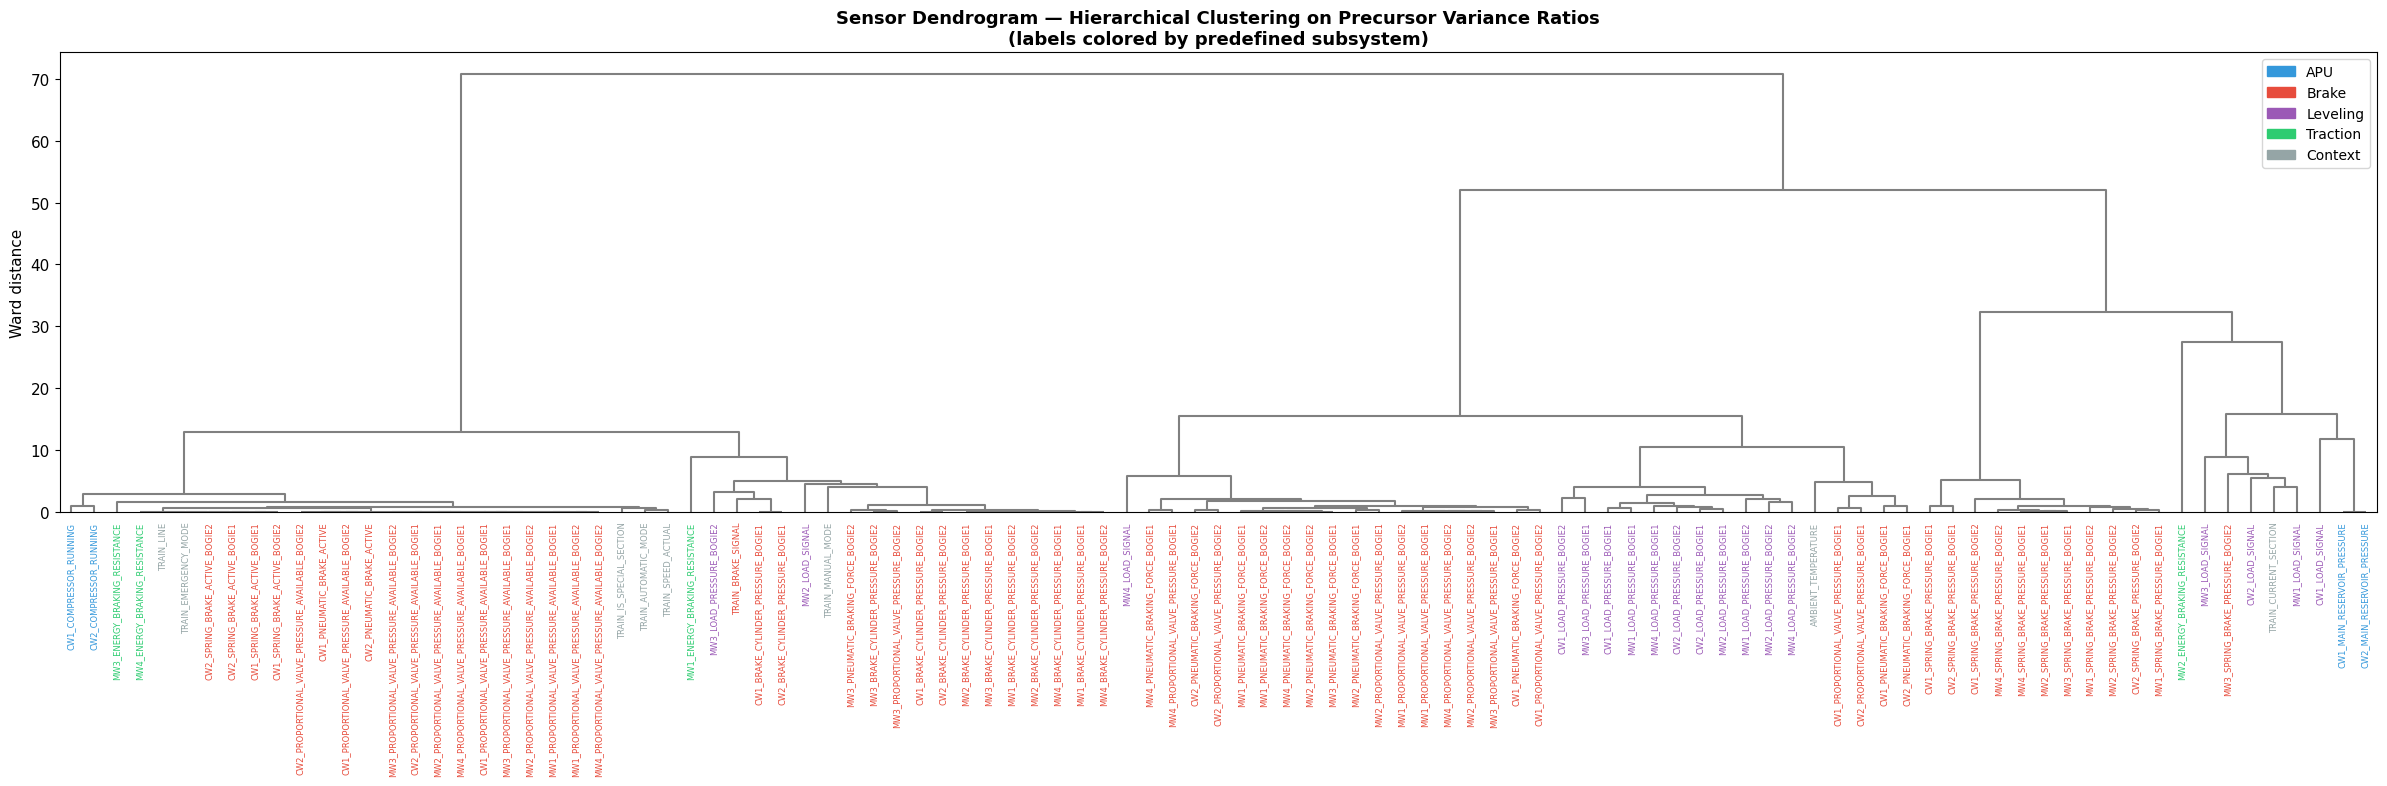

In [28]:
# Dendrogram — color-coded by subsystem
fig, ax = plt.subplots(figsize=(24, 8))

# Compute dendrogram
dn = dendrogram(
    Z,
    labels=sensor_names,
    leaf_rotation=90,
    leaf_font_size=6,
    ax=ax,
    color_threshold=0,       # all branches same color for now
    above_threshold_color='grey',
)

# Color the x-tick labels by subsystem
ss_colors = {'APU': '#3498db', 'Brake': '#e74c3c', 'Leveling': '#9b59b6',
             'Traction': '#2ecc71', 'Context': '#95a5a6'}
xlabels = ax.get_xticklabels()
for lbl in xlabels:
    sensor = lbl.get_text()
    ss = get_subsystem(sensor)
    lbl.set_color(ss_colors.get(ss, 'black'))

ax.set_title('Sensor Dendrogram — Hierarchical Clustering on Precursor Variance Ratios\n'
             '(labels colored by predefined subsystem)', fontsize=13, fontweight='bold')
ax.set_ylabel('Ward distance')

# Legend for subsystem colors
from matplotlib.patches import Patch
patches = [Patch(color=c, label=s) for s, c in ss_colors.items()]
ax.legend(handles=patches, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [29]:
# Try different numbers of clusters and show the composition
print('=== Cluster composition for different k values ===\n')

for k in [3, 4, 5, 6]:
    labels = fcluster(Z, t=k, criterion='maxclust')
    cluster_df = pd.DataFrame({
        'sensor': sensor_names,
        'subsystem': subsystem_labels,
        'cluster': labels
    })
    
    # Cross-tabulation: cluster vs subsystem
    ct = pd.crosstab(cluster_df['cluster'], cluster_df['subsystem'])
    print(f'--- k = {k} clusters ---')
    print(ct.to_string())
    print()

=== Cluster composition for different k values ===

--- k = 3 clusters ---
subsystem  APU  Brake  Context  Leveling  Traction
cluster                                           
1            2     33        6         2         3
2            0     22        1        12         0
3            2     12        1         4         1

--- k = 4 clusters ---
subsystem  APU  Brake  Context  Leveling  Traction
cluster                                           
1            2     33        6         2         3
2            0     22        1        12         0
3            0     11        0         0         0
4            2      1        1         4         1

--- k = 5 clusters ---
subsystem  APU  Brake  Context  Leveling  Traction
cluster                                           
1            2     33        6         2         3
2            0     22        1        12         0
3            0     11        0         0         0
4            2      1        1         4         0
5         

In [30]:
# Select final k based on the cross-tabulation above
K = 4

cluster_labels = fcluster(Z, t=K, criterion='maxclust')
cluster_df = pd.DataFrame({
    'sensor': sensor_names,
    'subsystem': subsystem_labels,
    'cluster': cluster_labels
})

# Add detection rate and median ratio from the ranking
cluster_df = cluster_df.merge(
    sensor_ranking[['sensor', 'detection_rate', 'median_ratio', 'median_lead_h']],
    on='sensor', how='left'
)

# Cluster profile: what does each cluster look like?
print(f'=== Final clustering: k = {K} ===\n')
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]
    ss_breakdown = members['subsystem'].value_counts().to_dict()
    ss_str = ', '.join(f'{ss}:{n}' for ss, n in sorted(ss_breakdown.items()))
    
    print(f'Cluster {c} ({len(members)} sensors): {ss_str}')
    print(f'  Mean detection rate : {members["detection_rate"].mean():.2f}')
    print(f'  Median var ratio    : {members["median_ratio"].median():.1f}')
    print(f'  Median lead time    : {members["median_lead_h"].median():.1f}h')
    print()

=== Final clustering: k = 4 ===

Cluster 1 (46 sensors): APU:2, Brake:33, Context:6, Leveling:2, Traction:3
  Mean detection rate : 0.16
  Median var ratio    : 3.4
  Median lead time    : 1.9h

Cluster 2 (35 sensors): Brake:22, Context:1, Leveling:12
  Mean detection rate : 0.34
  Median var ratio    : 3.6
  Median lead time    : 2.6h

Cluster 3 (11 sensors): Brake:11
  Mean detection rate : 1.00
  Median var ratio    : 269.6
  Median lead time    : 2.3h

Cluster 4 (9 sensors): APU:2, Brake:1, Context:1, Leveling:4, Traction:1
  Mean detection rate : 0.94
  Median var ratio    : 139.9
  Median lead time    : 4.2h



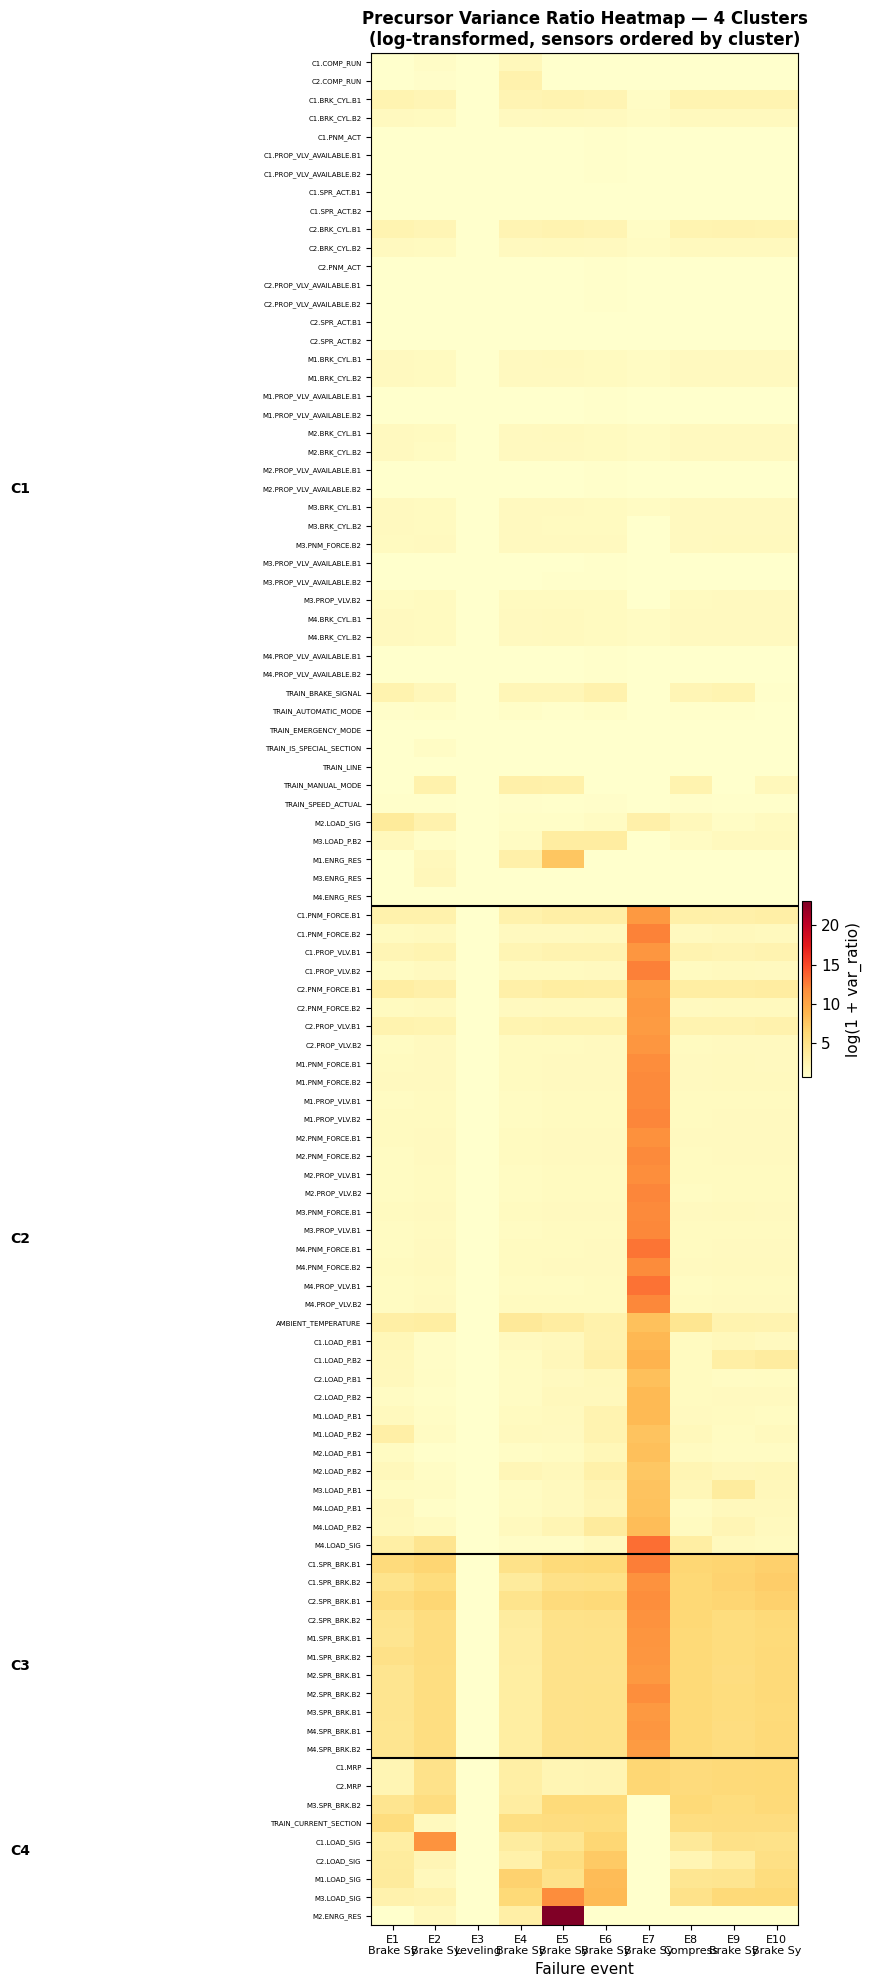

In [31]:
# Heatmap: variance ratio matrix ordered by cluster assignment
# This shows whether sensors within the same cluster behave similarly across events

# Sort sensors by cluster, then by subsystem within cluster
plot_order = cluster_df.sort_values(['cluster', 'subsystem', 'sensor'])['sensor'].tolist()
X_plot = X_log.loc[plot_order]

# Cluster boundaries for annotation
cluster_bounds = []
for c in sorted(cluster_df['cluster'].unique()):
    members = [s for s in plot_order if cluster_df.loc[cluster_df['sensor'] == s, 'cluster'].values[0] == c]
    start = plot_order.index(members[0])
    end = plot_order.index(members[-1]) + 1
    cluster_bounds.append((start, end, c))

fig, ax = plt.subplots(figsize=(14, 20))
im = ax.imshow(X_plot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='log(1 + var_ratio)')

# Event labels on x-axis
event_labels = [f'E{e}\n{train_events.loc[e, "failure_type"][:8]}' for e in event_cols]
ax.set_xticks(range(len(event_cols)))
ax.set_xticklabels(event_labels, fontsize=8)

# Sensor labels on y-axis (shortened)
def shorten(s):
    s = s.replace('CW1_', 'C1.').replace('CW2_', 'C2.')
    s = s.replace('MW1_', 'M1.').replace('MW2_', 'M2.').replace('MW3_', 'M3.').replace('MW4_', 'M4.')
    s = s.replace('_BOGIE1', '.B1').replace('_BOGIE2', '.B2')
    s = s.replace('BRAKE_CYLINDER_PRESSURE', 'BRK_CYL').replace('SPRING_BRAKE_PRESSURE', 'SPR_BRK')
    s = s.replace('PROPORTIONAL_VALVE_PRESSURE', 'PROP_VLV').replace('PNEUMATIC_BRAKING_FORCE', 'PNM_FORCE')
    s = s.replace('PNEUMATIC_BRAKE_ACTIVE', 'PNM_ACT').replace('PROPORTIONAL_VALVE_PRESSURE_AVAILABLE', 'PVP_AVAIL')
    s = s.replace('MAIN_RESERVOIR_PRESSURE', 'MRP').replace('COMPRESSOR_RUNNING', 'COMP_RUN')
    s = s.replace('LOAD_PRESSURE', 'LOAD_P').replace('LOAD_SIGNAL', 'LOAD_SIG')
    s = s.replace('ENERGY_BRAKING_RESISTANCE', 'ENRG_RES')
    s = s.replace('SPRING_BRAKE_ACTIVE', 'SPR_ACT')
    return s

ax.set_yticks(range(len(plot_order)))
ax.set_yticklabels([shorten(s) for s in plot_order], fontsize=5)

# Draw cluster boundaries
for start, end, c in cluster_bounds:
    ax.axhline(y=start - 0.5, color='black', linewidth=1.5)
    ax.text(-0.8, (start + end) / 2, f'C{c}', fontsize=10, fontweight='bold',
            ha='right', va='center', transform=ax.get_yaxis_transform())

ax.set_title(f'Precursor Variance Ratio Heatmap — {K} Clusters\n'
             f'(log-transformed, sensors ordered by cluster)', fontsize=12, fontweight='bold')
ax.set_xlabel('Failure event')
plt.tight_layout()
plt.show()

## 5. Compare Data-Driven Clusters to Predefined Subsystems

The central question of this thesis: **does the predefined subsystem grouping (APU, Brake, Leveling, Traction, Context) align with data-driven sensor clusters?**

We measure this with:
1. **Confusion matrix** — cluster vs. subsystem overlap (heatmap)
2. **Adjusted Rand Index (ARI)** — quantifies agreement between two partitions (1.0 = perfect match, 0.0 = random)
3. **Per-cluster sensor listing** — which sensors ended up where, and why

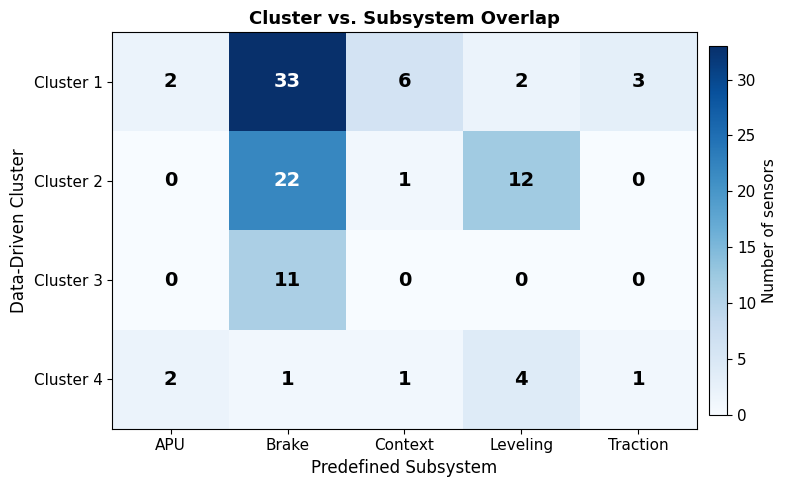

Adjusted Rand Index (ARI): 0.071
Normalized Mutual Info (NMI): 0.190

Interpretation:
  ARI = 1.0 means clusters perfectly match subsystems
  ARI = 0.0 means clusters are random w.r.t. subsystems
  ARI = 0.071 means weak agreement


In [32]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Cross-tabulation heatmap: cluster vs subsystem
ct = pd.crosstab(cluster_df['cluster'], cluster_df['subsystem'])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(ct.values, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Number of sensors')

# Annotate cells with counts
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        color = 'white' if val > ct.values.max() * 0.6 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=14, fontweight='bold', color=color)

ax.set_xticks(range(ct.shape[1]))
ax.set_xticklabels(ct.columns, fontsize=11)
ax.set_yticks(range(ct.shape[0]))
ax.set_yticklabels([f'Cluster {c}' for c in ct.index], fontsize=11)
ax.set_xlabel('Predefined Subsystem', fontsize=12)
ax.set_ylabel('Data-Driven Cluster', fontsize=12)
ax.set_title('Cluster vs. Subsystem Overlap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Agreement scores
ari = adjusted_rand_score(cluster_df['subsystem'], cluster_df['cluster'])
nmi = normalized_mutual_info_score(cluster_df['subsystem'], cluster_df['cluster'])
print(f'Adjusted Rand Index (ARI): {ari:.3f}')
print(f'Normalized Mutual Info (NMI): {nmi:.3f}')
print()
print('Interpretation:')
print('  ARI = 1.0 means clusters perfectly match subsystems')
print('  ARI = 0.0 means clusters are random w.r.t. subsystems')
print(f'  ARI = {ari:.3f} means {"moderate" if ari > 0.2 else "weak" if ari > 0.05 else "no"} agreement')

In [33]:
# Detailed sensor listing per cluster
print('=== Sensor Membership per Cluster ===\n')
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c].sort_values(
        ['subsystem', 'detection_rate'], ascending=[True, False]
    )
    print(f'--- Cluster {c} ({len(members)} sensors) ---')
    for _, row in members.iterrows():
        flag = '*' if row['detection_rate'] >= 0.5 else ' '
        print(f'  {flag} {row["subsystem"]:10s} | det={row["detection_rate"]:.0%} | '
              f'ratio={row["median_ratio"]:8.1f} | {row["sensor"]}')
    print()

print('(* = detection rate >= 50%)')

=== Sensor Membership per Cluster ===

--- Cluster 1 (46 sensors) ---
  * APU        | det=50% | ratio=     7.3 | CW2_COMPRESSOR_RUNNING
    APU        | det=0% | ratio=     3.4 | CW1_COMPRESSOR_RUNNING
  * Brake      | det=89% | ratio=    10.1 | CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1
  * Brake      | det=89% | ratio=    10.3 | CW2_BRAKE_CYLINDER_PRESSURE_BOGIE1
  * Brake      | det=88% | ratio=     7.3 | TRAIN_BRAKE_SIGNAL
    Brake      | det=0% | ratio=     3.8 | CW1_BRAKE_CYLINDER_PRESSURE_BOGIE2
    Brake      | det=0% | ratio=     1.1 | CW1_PNEUMATIC_BRAKE_ACTIVE
    Brake      | det=0% | ratio=     1.1 | CW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1
    Brake      | det=0% | ratio=     1.1 | CW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2
    Brake      | det=0% | ratio=     3.8 | CW2_BRAKE_CYLINDER_PRESSURE_BOGIE2
    Brake      | det=0% | ratio=     1.1 | CW2_PNEUMATIC_BRAKE_ACTIVE
    Brake      | det=0% | ratio=     1.1 | CW2_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1
    

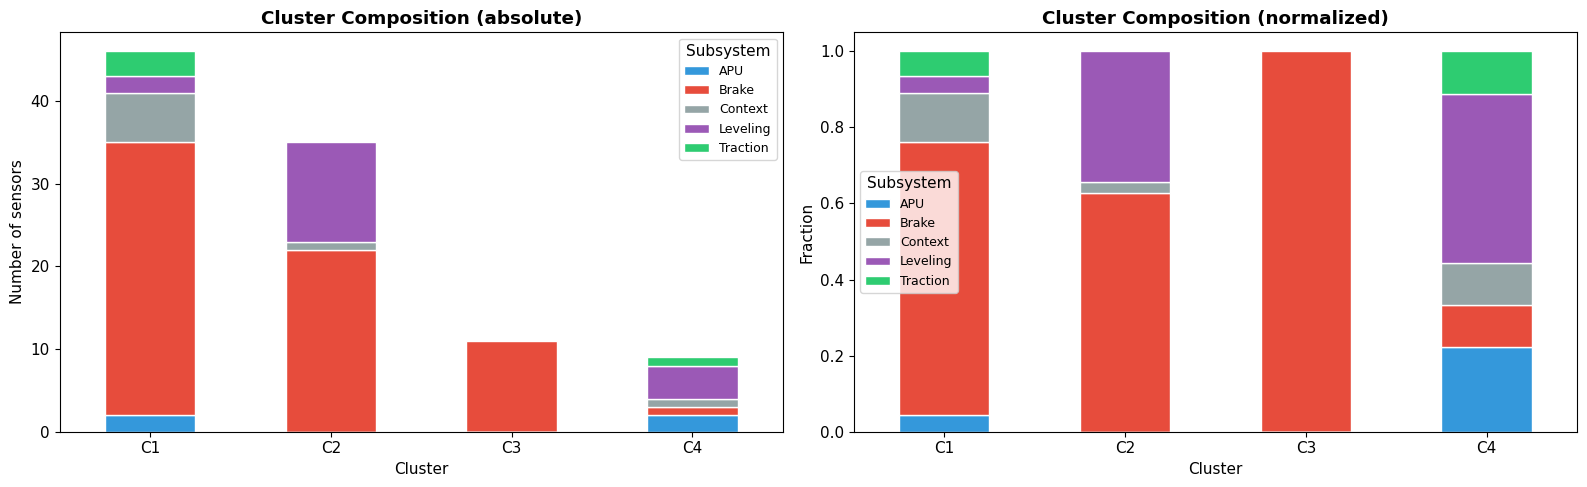

=== Cluster purity (fraction of dominant subsystem) ===
  Cluster 1: 72% Brake (33/46 sensors)
  Cluster 2: 63% Brake (22/35 sensors)
  Cluster 3: 100% Brake (11/11 sensors)
  Cluster 4: 44% Leveling (4/9 sensors)


In [34]:
# Stacked bar chart: subsystem composition within each cluster
ct_norm = ct.div(ct.sum(axis=1), axis=0)  # normalize rows to fractions

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: absolute counts (stacked bar)
ct.plot(kind='bar', stacked=True, ax=axes[0], 
        color=[colors[ss] for ss in ct.columns], edgecolor='white')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of sensors')
axes[0].set_title('Cluster Composition (absolute)', fontweight='bold')
axes[0].legend(title='Subsystem', fontsize=9)
axes[0].set_xticklabels([f'C{c}' for c in ct.index], rotation=0)

# Right: normalized (percentage)
ct_norm.plot(kind='bar', stacked=True, ax=axes[1],
             color=[colors[ss] for ss in ct_norm.columns], edgecolor='white')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Fraction')
axes[1].set_title('Cluster Composition (normalized)', fontweight='bold')
axes[1].legend(title='Subsystem', fontsize=9)
axes[1].set_xticklabels([f'C{c}' for c in ct_norm.index], rotation=0)

plt.tight_layout()
plt.show()

# Summary: cluster purity
print('=== Cluster purity (fraction of dominant subsystem) ===')
for c in ct.index:
    row = ct.loc[c]
    dominant = row.idxmax()
    purity = row.max() / row.sum()
    print(f'  Cluster {c}: {purity:.0%} {dominant} ({row.max()}/{row.sum()} sensors)')

## 6. Summary & Conclusions

This section consolidates the findings from the anomaly analysis and sensor clustering into actionable results for feature engineering.

In [ ]:
# Final summary table: all sensors with cluster assignment and precursor metrics
summary = cluster_df[['sensor', 'subsystem', 'cluster', 'detection_rate', 'median_ratio', 'median_lead_h']].copy()
summary = summary.sort_values(['cluster', 'subsystem', 'sensor']).reset_index(drop=True)

# Cluster interpretation labels
cluster_names = {
    1: 'Noise / No Signal',
    2: 'Moderate Signal',
    3: 'Strong Brake Precursor',
    4: 'Cross-Subsystem Early Warning',
}
summary['cluster_name'] = summary['cluster'].map(cluster_names)

print('=== Full Sensor Summary ===')
print(f'Total sensors: {len(summary)}')
print()
for c in sorted(summary['cluster'].unique()):
    grp = summary[summary['cluster'] == c]
    name = cluster_names[c]
    useful = (grp['detection_rate'] >= 0.5).sum()
    print(f'Cluster {c} — {name}: {len(grp)} sensors ({useful} useful)')
print()

# Count useful sensors per subsystem
print('=== Useful sensors (detection rate >= 50%) by subsystem ===')
useful_sensors = summary[summary['detection_rate'] >= 0.5]
useful_by_ss = useful_sensors.groupby('subsystem').size()
total_by_ss = summary.groupby('subsystem').size()
comparison = pd.DataFrame({'total': total_by_ss, 'useful': useful_by_ss}).fillna(0).astype(int)
comparison['pct'] = (100 * comparison['useful'] / comparison['total']).round(0).astype(int)
print(comparison.to_string())
print(f'\nTotal useful: {len(useful_sensors)} / {len(summary)} ({100*len(useful_sensors)/len(summary):.0f}%)')

In [ ]:
# Save cluster assignments for use in feature engineering (Notebook 03)
output_path = os.path.join('..', 'outputs', 'sensor_clusters.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
summary.to_csv(output_path, index=False)
print(f'Saved sensor cluster assignments to: {output_path}')
print(f'Columns: {summary.columns.tolist()}')

### Key Findings

**1. Most sensors are uninformative for failure prediction.**  
Only 36 of 101 sensors (detection rate >= 50%) show reliable precursor signals. The remaining 65 are binary flags, constant-value sensors, or weak responders. A flat model using all 101 wastes capacity on noise.

**2. Spring brake pressure is the dominant precursor signal.**  
All 11 spring brake pressure sensors (Cluster 3) achieve 100% detection rate with median variance ratios of 250–618x. They form a pure, homogeneous Brake cluster — the strongest evidence for subsystem-aware grouping.

**3. Cross-subsystem effects exist through the shared pneumatic system.**  
Cluster 4 contains sensors from APU, Leveling, Brake, and Traction that all react to failures. This reflects the physical reality: reservoir pressure (APU) feeds the brake and leveling systems, so a pressure anomaly propagates across subsystems.

**4. Predefined subsystem grouping is partially supported by the data.**  
Brake sensors split into strong (Cluster 3) and weak (Clusters 1-2) groups — indicating that subsystem-aware features should focus on the most informative sensors within each subsystem rather than using all sensors equally. APU and Leveling sensors are scattered across clusters based on signal strength, suggesting that sensor selection within subsystems matters.

**5. BOGIE1 vs BOGIE2 asymmetry.**  
CW1/CW2 proportional valve and braking force sensors on BOGIE1 show 100% detection, while BOGIE2 equivalents show only 11%. Failures manifest asymmetrically — one side of the bogie is affected before the other.

### Implications for Subsystem-Aware Feature Engineering

These findings inform the design of structured subsystem-aware features:

- **Sensor selection within subsystems:** Not all sensors in a subsystem are equally useful. Brake has 67 sensors but only 19 carry precursor signals. Subsystem-aware features should prioritize informative sensors.
- **Cross-subsystem interactions:** The pneumatic system links APU, Brake, and Leveling. Feature representations should capture these cross-subsystem dependencies, not treat subsystems as fully independent.
- **Signal strength hierarchy:** Spring brake pressure (Brake) and main reservoir pressure (APU) are the strongest precursors. Feature engineering should reflect this importance difference.

The next notebook will build subsystem-aware feature representations informed by these findings and compare them against a flat baseline.

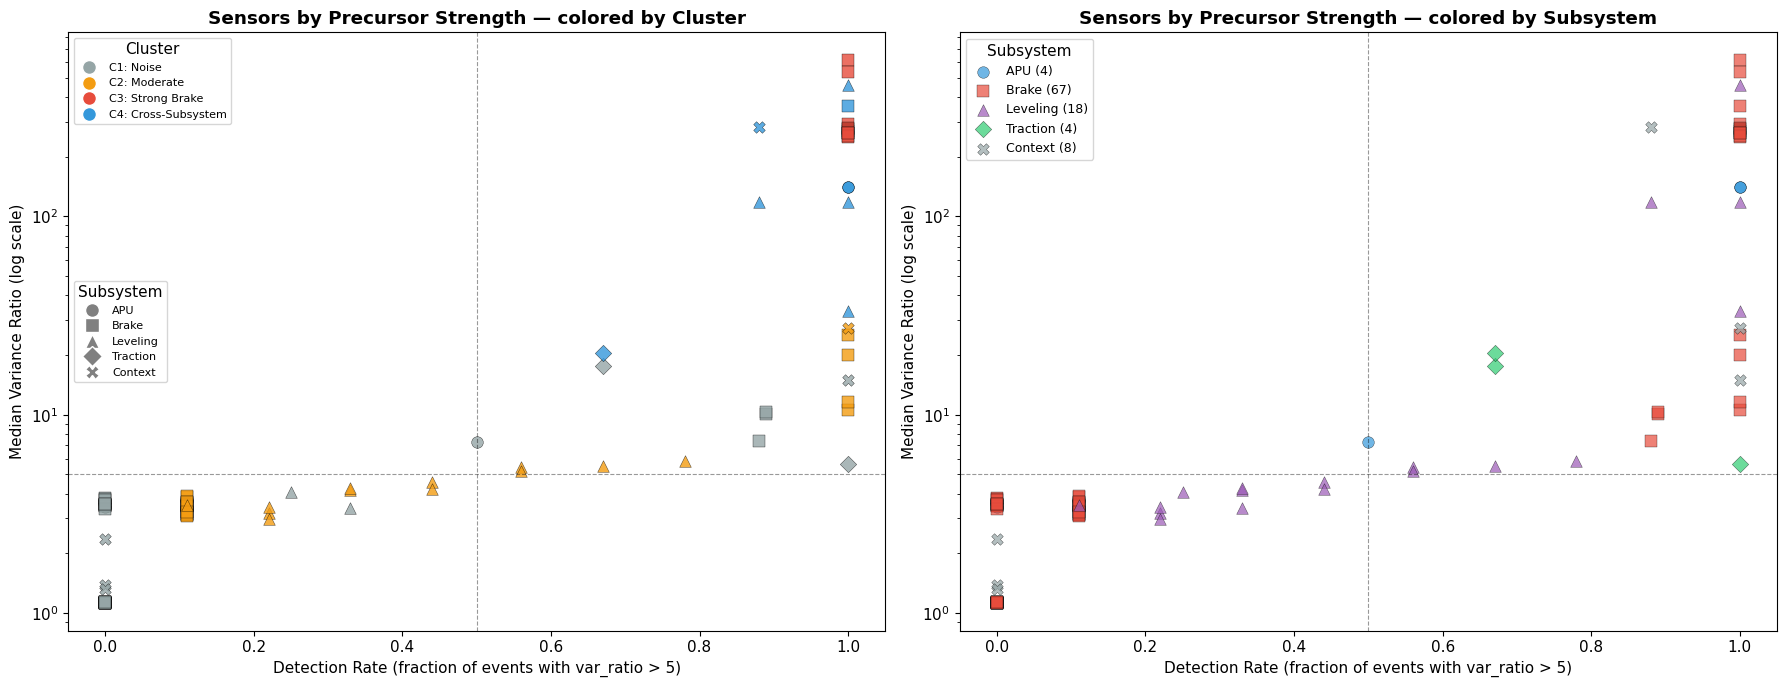

Dashed lines: detection rate = 50% (horizontal) and var_ratio = 5 (vertical)
Top-right quadrant = useful sensors | Bottom-left quadrant = noise


In [44]:
cluster_colors = {1: '#95a5a6', 2: '#f39c12', 3: '#e74c3c', 4: '#3498db'}
cluster_names_short = {1: 'C1: Noise', 2: 'C2: Moderate', 3: 'C3: Strong Brake', 4: 'C4: Cross-Subsystem'}
ss_markers = {'APU': 'o', 'Brake': 's', 'Leveling': '^', 'Traction': 'D', 'Context': 'X'}

# Build plot dataframe
plot_df = cluster_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: colored by CLUSTER, shaped by subsystem ---
ax = axes[0]
for c in sorted(plot_df['cluster'].unique()):
    for ss in ['APU', 'Brake', 'Leveling', 'Traction', 'Context']:
        subset = plot_df[(plot_df['cluster'] == c) & (plot_df['subsystem'] == ss)]
        if len(subset) == 0:
            continue
        ax.scatter(subset['detection_rate'], subset['median_ratio'],
                   c=cluster_colors[c], marker=ss_markers[ss],
                   s=70, alpha=0.8, edgecolors='black', linewidths=0.3)

from matplotlib.lines import Line2D
cluster_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_colors[c],
                           markersize=10, label=cluster_names_short[c]) for c in sorted(cluster_colors)]
ss_handles = [Line2D([0], [0], marker=ss_markers[ss], color='w', markerfacecolor='grey',
                      markersize=10, label=ss) for ss in ss_markers]
leg1 = ax.legend(handles=cluster_handles, title='Cluster', loc='upper left', fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=ss_handles, title='Subsystem', loc='center left', fontsize=8)
ax.set_xlabel('Detection Rate (fraction of events with var_ratio > 5)')
ax.set_ylabel('Median Variance Ratio (log scale)')
ax.set_yscale('log')
ax.axhline(y=5, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_title('Sensors by Precursor Strength — colored by Cluster', fontweight='bold')

# --- Right: colored by SUBSYSTEM, shaped by subsystem ---
ax = axes[1]
for ss in ['APU', 'Brake', 'Leveling', 'Traction', 'Context']:
    subset = plot_df[plot_df['subsystem'] == ss]
    ax.scatter(subset['detection_rate'], subset['median_ratio'],
               c=colors[ss], marker=ss_markers[ss],
               s=70, alpha=0.7, edgecolors='black', linewidths=0.3,
               label=f'{ss} ({len(subset)})')

ax.legend(title='Subsystem', loc='upper left', fontsize=9)
ax.set_xlabel('Detection Rate (fraction of events with var_ratio > 5)')
ax.set_ylabel('Median Variance Ratio (log scale)')
ax.set_yscale('log')
ax.axhline(y=5, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_title('Sensors by Precursor Strength — colored by Subsystem', fontweight='bold')

plt.tight_layout()
plt.show()

print('Dashed lines: detection rate = 50% (horizontal) and var_ratio = 5 (vertical)')
print('Top-right quadrant = useful sensors | Bottom-left quadrant = noise')